## The script load raw images from epixquad1kfps data
### Yusong, Starting on 2025/12/29, Sunnyvale
#### The script is the basic LCLS-II DataSource based analysis on the epix.raw.calib
#### Load the raw IoC, threshold/raw averaging, running hitFinding analysis
#### Runnign the HitFinding analysis and invest the parameter spaces
#### Check the statistics after the HitFinding analysis
#### This script running through the PVs and looking into the statistics with different conditions
#### Further modify the script for loading the Bi ePix data (02/27/2026)
##### Ref: LCLS-II DAQ and DataSource: https://confluence.slac.stanford.edu/spaces/LCLSIIData/pages/267391733/psana#psana-Environment
##### Ref: LCLS-II UED related data analysis: https://docs.google.com/document/d/1u03HnIyQ5vY1g3JhSzi9mqnfw6FGB3QSnVwpfn8AMlc/edit?tab=t.0

In [1]:
import os,sys
import numpy as np
import configparser
import matplotlib.pyplot as plt
import matplotlib
import argparse
from psana import DataSource
from numba import jit, njit
import scipy.ndimage.measurements as smt
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *
from UEDePixTools import *
from tqdm import tqdm
from PIL import Image
from matplotlib.colors import LogNorm
%matplotlib widget

In [2]:
# Quick functions
# Load the save data and plot the results
def ePixRawFrameLoad(fileLoad_name): # Load the saved 
    pathAnaLoad = '/sdf/scratch/lcls/ds/ued/ued1015999/scratch/' # Save the acetophenone signal
    pathAnaLoad_name = pathAnaLoad+fileLoad_name
    data_load   = np.load(pathAnaLoad_name, allow_pickle=True).item()
    step_v_evt  = data_load['step_v_evt']
    img_raw_evts_select = data_load['img_raw_evts_select']
    return step_v_evt,img_raw_evts_select

In [3]:
# Check detector and scan variables
if 1 == 1:
    !detnames    exp='ued1015999',run=168 # non-epics detector names 
    !detnames -s exp='ued1015999',run=168 # scan variables
    if 1 == 1:
        !detnames -e exp='ued1015999',run=168 # epics detector names

---------------------------
Name            | Data Type
---------------------------
triginfo        | triginfo 
timing          | raw      
epicsinfo       | epicsinfo
epixquad1kfps   | raw      
epixquad1kfpshw | config   
---------------------------
-----------------------------
Name              | Data Type
-----------------------------
step_value        | raw      
step_docstring    | raw      
UED:USR:MMN:14:01 | raw      
-----------------------------
---------------------------------------------------------------------------------
Detector Name                           | Epics Name                             
---------------------------------------------------------------------------------
StaleFlags                              |                                        
MOTR_MCN_UED_03_CH1_2ND_PITCH           | UED:USR:MMN:03:01.RBV                  
MOTR_MCN_UED_03_CH3_2ND_Y               | UED:USR:MMN:03:03.RBV                  
MOTR_MCN_UED_03_CH4_2ND_Z               | UED:

In [4]:
# Check the Pedestal scan if needed: make sure the run is a pedestal run
if 1 == 0:
    ds = DataSource(exp='ued1015999',run=263) # Run 24 is one of the Pedestal scan for the commissioning experiment
    myrun = next(ds.runs())
    step_value = myrun.Detector('step_value')
    step_docstring = myrun.Detector('step_docstring')
    for step in myrun.steps():
        print(step_value(step),step_docstring(step))
        for evt in step.events():
            pass

In [5]:
# Set up an array looking into the single frames of the ePiX data
if 1 == 0:
    num_steps = np.shape(np.arange(52,56.25,0.25))[0]
    # shots_array = np.array()
    print(num_steps)
    arr = np.arange(1080 * 17)   # example: 5 blocks
    block_size = 1080
    pick = np.linspace(0, block_size - 1, 100, dtype=int)
    shots_array_pick = arr.reshape(-1, block_size)[:, pick]
    print(shots_array_pick)

In [6]:
# exp and run infor and load raw data using LCLS DataSource
exp = 'ued1015999'  # experiment
run = 126 # charge scan of Al on the 
# max_events = num_steps*1080 # how many shots to load
max_events = 540 # how many shots to load
# ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load .xtc using DataSource, normal experiment and run
ds     = DataSource(exp=exp, run=run) # Load .xtc using DataSource, normal experiment and run
myrun  = next(ds.runs()) # Load runs
if 1 == 1: # the scanning PVs
    scan_motor = 'UED:USR:MMN:14:01' # scanning stage
    step_v = myrun.Detector(scan_motor) # Load stage position
epix   = myrun.Detector('epixquad1kfps') # Detector
evt    = next(myrun.events()) # event
steps  = myrun.steps() 

In [7]:
# Investigate the PVs and differentiate the PV dependent frames
# Load the PV values and check how to do the scans
step_v_evt   = []
thrs_raw     = 40 # Set a threshold for the ePix raw frame
# img_raw_evts_select = []
evt_count = 0 # counters for evt
for evt in myrun.events():
    if 0 == 1:
        if (evt_count%1080 >= 0) and (evt_count%1080 <=49):
            # print(evt_count)
            # calib = epix.raw.calib(evt) # Load modules
            # img_raw_evts_select.append(epix.raw.image(evt,calib))
            step_v_evt.append(step_v(evt))
    if 1 == 1:
        evt_count  = evt_count + 1
        if ((evt_count+1)%540 == 0):
            print('Loading the frame at '+str(evt_count+1))
        # calib = epix.raw.calib(evt) # Load modules
        # img_raw_evts_select.append(epix.raw.image(evt,calib))
        step_v_evt.append(step_v(evt))
# img_raw_evts_select = np.array(img_raw_evts_select) # Put it in to an array
step_v_evt = np.array(step_v_evt)
print('Finish loading the ePix IoC raw frames')

Loading the frame at 540
Loading the frame at 1080
Loading the frame at 1620
Loading the frame at 2160
Loading the frame at 2700
Loading the frame at 3240
Loading the frame at 3780
Loading the frame at 4320
Loading the frame at 4860
Loading the frame at 5400
Loading the frame at 5940
Loading the frame at 6480
Loading the frame at 7020
Loading the frame at 7560
Loading the frame at 8100
Loading the frame at 8640
Loading the frame at 9180
Loading the frame at 9720
Loading the frame at 10260
Loading the frame at 10800
Loading the frame at 11340
Loading the frame at 11880
Loading the frame at 12420
Loading the frame at 12960
Loading the frame at 13500
Loading the frame at 14040
Finish loading the ePix IoC raw frames


[50.4987475  51.00174499 51.50774246 52.00173999 52.50173749 52.999735
 53.4997325  53.99973    54.50072749 54.99672502 55.50172249 56.00071999]


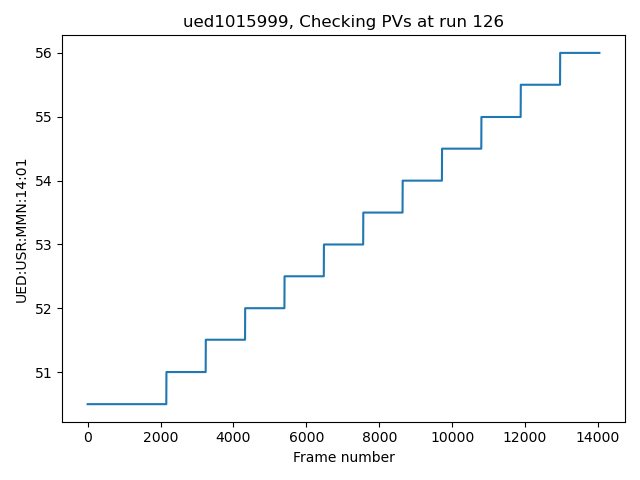

In [8]:
# Investigate the PV valves
step_v_unique = np.unique(step_v_evt) # The unique value of the PVs
print(step_v_unique)
plt.figure()
plt.plot(step_v_evt)
plt.xlabel('Frame number')
plt.ylabel(scan_motor)
plt.title(exp+', Checking PVs at run '+str(run))

plt.tight_layout()
plt.show()

In [9]:
# Load the data for a few shots at different PVs using LCLS DataSource
exp = 'ued1015999'  # experiment
run = 126 # charge scan of Al on the 
# max_events = num_steps*1080 # how many shots to load
max_events = 540 # how many shots to load
# ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load .xtc using DataSource, normal experiment and run
ds     = DataSource(exp=exp, run=run) # Load .xtc using DataSource, normal experiment and run
myrun  = next(ds.runs()) # Load runs
if 1 == 1: # the scanning PVs
    scan_motor = 'UED:USR:MMN:14:01' # scanning stage
    step_v = myrun.Detector(scan_motor) # Load stage position
epix   = myrun.Detector('epixquad1kfps') # Detector
evt    = next(myrun.events()) # event
steps  = myrun.steps()

# Loop the evt and load ePix data
# Load 100 frame for each PV
PV_step_i = 2 # Choose at which step
img_shape    = [775,793] # Define the dimention of the image
calib_evts   = [] # Modules
# img_raw_evts = [] # Raw images
step_v_evt   = []
thrs_raw     = 40 # Set a threshold for the ePix raw frame
img_raw_evts_select = []
# img_raw_evts_select = np.zeros((100*12,775,793))
evt_count = 0 # counters for evt
for evt in myrun.events():
    if (step_v(evt) == step_v_unique[PV_step_i]) and (evt_count<100):
        evt_count  = evt_count + 1
        calib = epix.raw.calib(evt) # Load modules
        img_raw_evts_select.append(epix.raw.image(evt,calib))
        step_v_evt.append(step_v(evt))
img_raw_evts_select = np.array(img_raw_evts_select) # Put it in to an array
step_v_evt = np.array(step_v_evt)

In [10]:
for i_pv,pv_chose in enumerate(step_v_unique[:]):
    print(pv_chose)
    exp = 'ued1015999'  # experiment
    run = 126 # charge scan of Al on the 
    # max_events = num_steps*1080 # how many shots to load
    max_events = 540 # how many shots to load
    # ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load .xtc using DataSource, normal experiment and run
    ds     = DataSource(exp=exp, run=run) # Load .xtc using DataSource, normal experiment and run
    myrun  = next(ds.runs()) # Load runs
    if 1 == 1: # the scanning PVs
        scan_motor = 'UED:USR:MMN:14:01' # scanning stage
        step_v = myrun.Detector(scan_motor) # Load stage position
    epix   = myrun.Detector('epixquad1kfps') # Detector
    evt    = next(myrun.events()) # event
    steps  = myrun.steps()
    
    # Loop the evt and load ePix data
    # Load 100 frame for each PV
    PV_step_i = 2 # Choose at which step
    PV_step_chose = 2 # Choose at which step

    img_shape    = [775,793] # Define the dimention of the image
    calib_evts   = [] # Modules
    # img_raw_evts = [] # Raw images
    step_v_evt   = []
    thrs_raw     = 40 # Set a threshold for the ePix raw frame
    img_raw_evts_select = []
    # img_raw_evts_select = np.zeros((100*12,775,793))
    evt_count = 0 # counters for evt
    for evt in myrun.events():
        if (step_v(evt) == pv_chose) and (evt_count<100):
            evt_count  = evt_count + 1
            calib = epix.raw.calib(evt) # Load modules
            img_raw_evts_select.append(epix.raw.image(evt,calib))
            step_v_evt.append(step_v(evt))
    img_raw_evts_select = np.array(img_raw_evts_select) # Put it in to an array
    step_v_evt = np.array(step_v_evt)
    # Save the data of the npy array
    if 1 == 0:
        pathAnaSave = '/sdf/data/lcls/ds/ued/ued1015999/results/yusongl/pro_data_save/';
        # Save the acetophenone signal
        pathAnaSave_name = pathAnaSave + exp +'_'+str(run)+'_raw_frames_PV_at_'+str(round(pv_chose,1))+'.npy'
        np.save(pathAnaSave_name, {'step_v_evt':step_v_evt,'img_raw_evts_select':img_raw_evts_select})

50.498747505
51.00174499
51.50774246
52.00173999
52.50173749
52.999735
53.4997325
53.99973
54.500727495
54.996725015
55.50172249
56.000719995


(100, 794, 778)


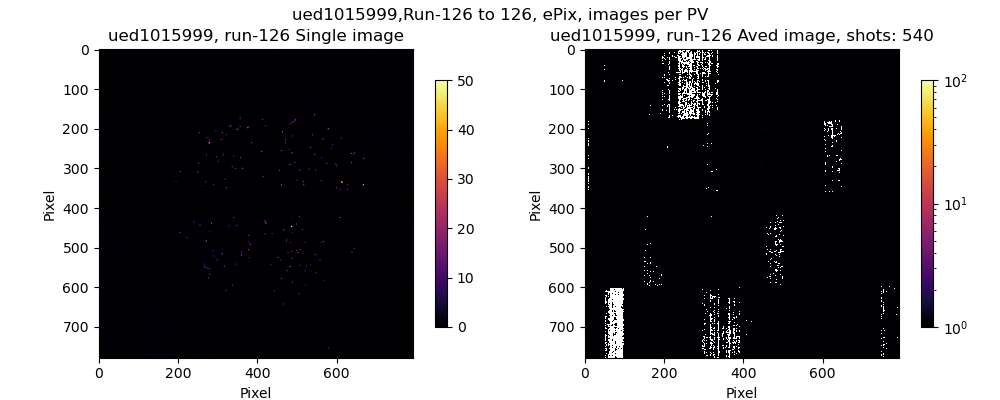

In [11]:
print(img_raw_evts_select.shape)
# Check the individual images and averaged images
img_sgl = img_raw_evts_select[5] # Check one image
plt.figure(figsize = (10,4))
plt.suptitle(exp+',Run-'+str(run)+' to '+str(run)+', ePix, images per PV')

plt.subplot(121)
plt.imshow(np.transpose(img_sgl),cmap = 'inferno', vmin=0,vmax=50);plt.colorbar(shrink=0.8)
plt.title(exp+', run-'+str(run)+' Single image');plt.xlabel('Pixel');plt.ylabel('Pixel');

plt.subplot(122)
img_raw_evts_ave = img_raw_evts_select[0:max_events].mean(axis=0);
# plt.imshow(img_raw_evts_ave, cmap='inferno');
plt.imshow(np.transpose(img_raw_evts_ave),norm=LogNorm(1,100), cmap='inferno');plt.colorbar(shrink=0.8)
plt.title(exp+', run-'+str(run)+' Aved image, shots: '+str(max_events));plt.xlabel('Pixel');plt.ylabel('Pixel');

plt.tight_layout()
plt.show()

# Save the data of the npy array
if 1 == 0:
    pathAnaSave = '/sdf/data/lcls/ds/ued/ued1015999/results/yusongl/pro_data_save/';
    # Save the acetophenone signal
    pathAnaSave_name = pathAnaSave + exp +'_'+str(run)+'_raw_frames_PV_at_'+str(round(step_v_unique[PV_step_i],1))+'.npy'
    np.save(pathAnaSave_name, {'step_v_evt':step_v_evt,'img_raw_evts_select':img_raw_evts_select})

In [12]:
# Load the data from saved .npy file
if 1 == 0:
    fileLoad_name = 'ued1015999_126_raw_frames_PV_at_54.0.npy'
    step_v_evt,img_raw_evts_select = ePixRawFrameLoad(fileLoad_name)

    print(img_raw_evts_select.shape)
    # Check the individual images and averaged images
    img_sgl = img_raw_evts_select[5] # Check one image
    plt.figure(figsize = (10,4))
    plt.suptitle(exp+',Run-'+str(run)+' to '+str(run)+', ePix, images PV at '+str(step_v_evt[0]))
    
    plt.subplot(121)
    plt.imshow(np.transpose(img_sgl),cmap = 'inferno', vmin=0,vmax=50);plt.colorbar(shrink=0.8)
    plt.title(exp+', run-'+str(run)+' Single image');plt.xlabel('Pixel');plt.ylabel('Pixel');
    
    plt.subplot(122)
    img_raw_evts_ave = img_raw_evts_select[0:max_events].mean(axis=0);
    # plt.imshow(img_raw_evts_ave, cmap='inferno');
    plt.imshow(np.transpose(img_raw_evts_ave),norm=LogNorm(1,20), cmap='inferno');plt.colorbar(shrink=0.8)
    plt.title(exp+', run-'+str(run)+' Aved image, shots: '+str(step_v_evt.shape[0]));plt.xlabel('Pixel');plt.ylabel('Pixel');
    
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/sdf/scratch/lcls/ds/ued/ued1015999/scratch/ued1015999_126_raw_frames_PV_at_50.5.npy'

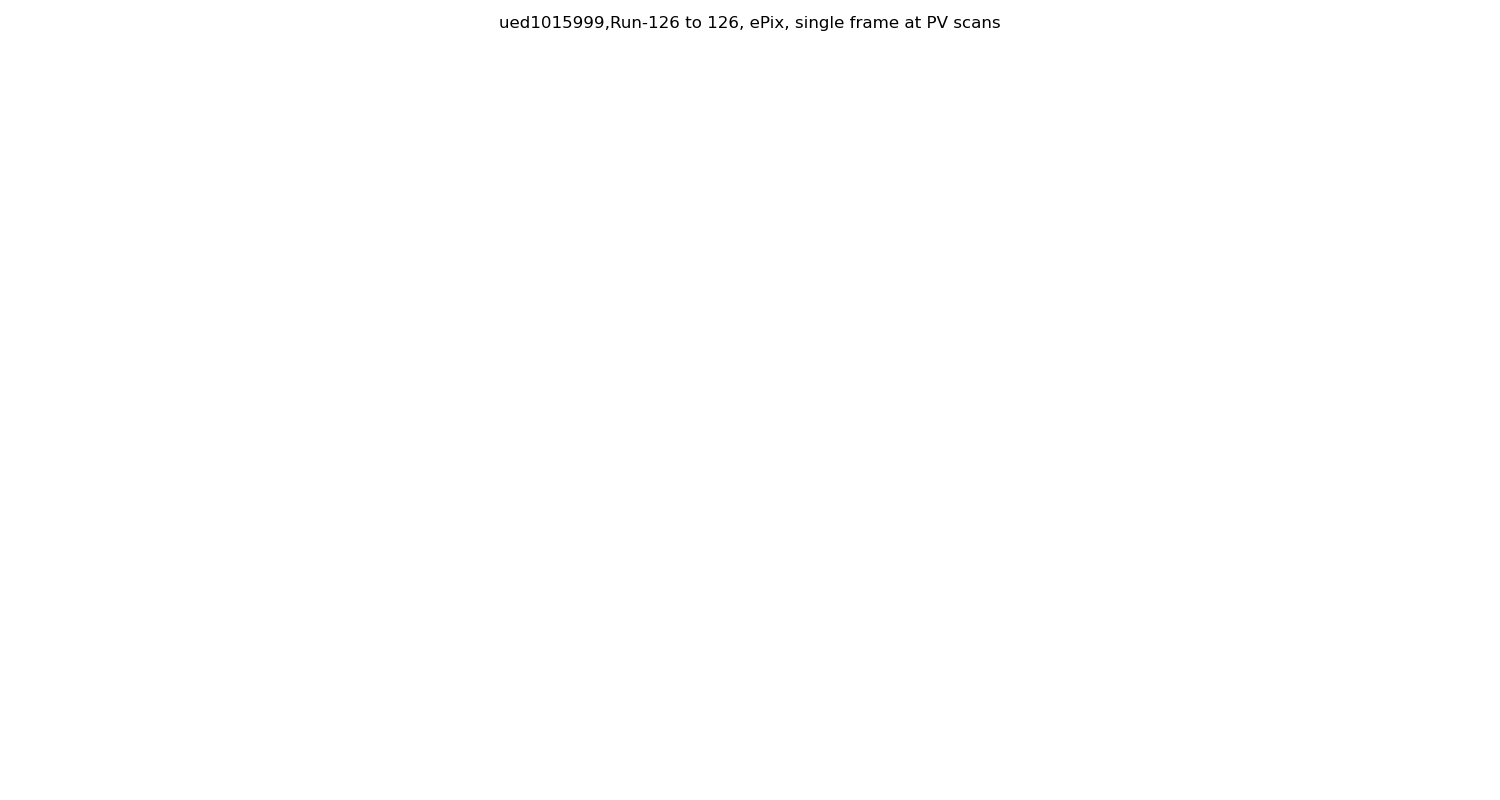

In [15]:
# Plot the signal in a for loop
PVs_to_load = np.arange(50.5,56.5,0.5)

plt.figure(figsize=(15,8))
plt.suptitle(exp+',Run-'+str(run)+' to '+str(run)+', ePix, single frame at PV scans')
for i_pv,pv_chose in enumerate(PVs_to_load):
    fileLoad_name = 'ued1015999_126_raw_frames_PV_at_'+str(pv_chose)+'.npy'
    step_v_evt,img_raw_evts_select = ePixRawFrameLoad(fileLoad_name)
    img_sgl = img_raw_evts_select[5] # Check one image
    plt.subplot(3,5,i_pv+1)
    plt.imshow(np.transpose(img_sgl),cmap = 'inferno', vmin=0,vmax=30);plt.colorbar(shrink=0.5)
    plt.title('PV at '+str(pv_chose));plt.xlabel('Pixel');plt.ylabel('Pixel');
plt.tight_layout()
plt.show()
    

In [ ]:
# Averaged iamges
plt.figure(figsize=(15,8))
plt.suptitle(exp+',Run-'+str(run)+' to '+str(run)+', ePix, Averaged frame at PV scans')
for i_pv,pv_chose in enumerate(PVs_to_load):
    fileLoad_name = 'ued1015999_126_raw_frames_PV_at_'+str(pv_chose)+'.npy'
    step_v_evt,img_raw_evts_select = ePixRawFrameLoad(fileLoad_name)
    img_sgl = img_raw_evts_select[5] # Check one image
    img_raw_evts_ave = img_raw_evts_select.mean(axis=0);

    plt.subplot(3,5,i_pv+1)
    plt.imshow(np.transpose(img_raw_evts_ave),norm=LogNorm(1,100), cmap='inferno');plt.colorbar(shrink=0.5)
    plt.title('PV at '+str(pv_chose));plt.xlabel('Pixel');plt.ylabel('Pixel');
plt.tight_layout()
plt.show()

In [ ]:
# Define some trial peak finding parameters
max_electrons = 1000 # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal


# threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
# min_signal    = 125   # Min intensity to be considered as electron signal

# threshold     = 25    # Threshold for peak finding, pixel intensity below this is filtered
# min_signal    = 100   # Min intensity to be considered as electron signal

# delete the dataSource to obtain the new DataSource
try:
    ds  # Try to access the variable
    print("ds exists!")
    print("ds deleted!")
    del ds
except NameError:
    print("ds does not exist.")

In [ ]:
# Running the peak finding 
beamCenter = np.array([397,309]) # set the center manually if needed
calib_evts     = [] # Modules of each evt
img_raw_evts   = [] # Raw images
x_evts         = [] # Peak X coordinates
y_evts         = [] # Peak Y coordinates
Intensity_evts = [] # Peak intenisties
Size_evts      = [] # Peak pixel size
n_peaks_evts   = [] # 
step_evts      = [] # Delay stage position
max_events     = 450 # Load a few frames
# Load the data from xtc files

exp = 'ued1015999'  # experiment
run = 126 # charge scan of Al on the 

# ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load the xtc file using DataSource infrastructure
ds     = DataSource(exp=exp, run=run) # Load the xtc file using DataSource infrastructure, all event
myrun  = next(ds.runs()) # Load runs
epix   = myrun.Detector('epixquad1kfps')
evt    = next(myrun.events())
if 1 == 1: # the scanning PVs
    scan_motor = 'UED:USR:MMN:14:01' # scanning stage
    step_v = myrun.Detector(scan_motor) # Load stage position

PV_step_chose = 1 # Choose at which scan step
pv_chose = step_v_unique[PV_step_chose]
evt_count = 0 # Counter of the event
for evt in myrun.events():# sometimes dectecor doesn't have 'epixquad' resulting in badness
    if (step_v(evt) == pv_chose) and (evt_count<540):
        calib = epix.raw.calib(evt)
        if calib is None: # this can return none, skip if it does
            continue
        evt_count = evt_count + 1;
        if evt_count%100 == 0:
            print('Looking at evt # '+str(evt_count))
    
        # define output arrays for peaks then populate them
        n_peaks = np.zeros(calib.shape[0])
        x = np.zeros((calib.shape[0], max_electrons))
        y = np.zeros((calib.shape[0], max_electrons))
        intensities = np.zeros((calib.shape[0], max_electrons))
        sizes = np.zeros((calib.shape[0], max_electrons))
        
        # The the peakFinding algrithem
        for i,module in enumerate(calib): # loop the number of quadrants
            n, _x, _y, _ints, _sizes = blobCounter(module, threshold, min_signal)
            n_peaks[i] = n
            # either fill in first max_electrons if n>max_electrons, or fill in first n
            if n > max_electrons:
                x[i] = _x[:max_electrons]
                y[i] = _y[:max_electrons]
                intensities[i] = _ints[:max_electrons]
                sizes[i] = _sizes[:max_electrons]
            else:
                x[i][:n] = _x
                y[i][:n] = _y
                intensities[i][:n] = _ints
                sizes[i][:n] = _sizes
        calib_evts.append(calib)
        x_evts.append(x);
        y_evts.append(y);
        Intensity_evts.append(intensities);
        Size_evts.append(sizes);
        step_evts.append(0); # if not existed
        # step_evts.append(step_value);
        n_peaks_evts.append(n_peaks)
x_evts = np.array(x_evts)
y_evts = np.array(y_evts)
Intensity_evts = np.array(Intensity_evts)
Size_evts = np.array(Size_evts)
n_peaks_evts = np.array(n_peaks_evts)
step_evts = np.array(step_evts)
print(str(evt_count)+' evts are loaded')
print('Finish peak finding')
print('Delays are:'+str(np.unique(step_evts)));

In [ ]:
# Plot the results of trial peakFinding results
# Plot the number of peaks found at each quad
# plot number of electron found per shot
NumEle = np.count_nonzero(x_evts,axis=2)
fig, axes = plt.subplots(1,2,figsize=(8, 4))
# cmapLim = [0,100]
for i_mdl in range(4):
     axes[0].plot(NumEle[:,i_mdl],label=r"Ave ele Module %i: %i"%(i_mdl,np.mean(NumEle[:,i_mdl])))
axes[0].legend(framealpha=0)
axes[0].set_xlabel('evts');axes[0].set_ylabel('Num Pekas');axes[0].set_title('Run '+str(run)+', Hits Found, threshold '+str(threshold));

bins_intn=np.arange(80,1000,5)
for i_mdl in range(4):
    hist_intn, bin_edges = np.histogram(Intensity_evts[:,i_mdl,:].flatten(), bins = bins_intn)
    axes[1].plot(bin_edges[0:-1],hist_intn,label=r"Ele intn Module %i"%(i_mdl))
axes[1].legend(framealpha=0)
axes[1].set_xlabel('Intensity');axes[1].set_ylabel('Num Peaks');axes[1].set_title('Run '+str(run)+', Peak intensity, min_signal '+str(min_signal));
plt.xlim([0,1000])
plt.tight_layout()
plt.show()

In [ ]:
NumEle

In [ ]:
# Put together the hitogram images
scale                    = 1 # - integer, the scale by which the output image will exceed the size of the detector (eg 3 breaks each pixel into 9) to take advantage of sub-pixel interpolation of peak centers.  1 returns images the same size as the detector, it is advised not to set much above 10.
filter_int_min           = 100 # - The minimum peak intensity to be included, typically 125.
filter_int_max           = 100000 # - The maximum peak intensity to be considered, useful for cosmic ray removal, direct beam removal, or to suppress peaks from multiple electron hits.
filter_size_min          = 1 #- The minimum peak size, in pixels, to be considered.  Typically 1.
filter_size_max          = 2000 # - The maximum peak size, in pixels, to be considered.  For limiting to single electron counting should be 4, to include double electron hits 8, or higher for many electrons.
count_multiple_electrons = 1 # - 0 or 1.  0 - all peaks are assigned as single electron.  1 - the peak intensity is used to calculate the most likely number of electrons contributing.  This is calculated as max(1, intensity//electron_signal).
apply_centroid_offset    = 0 # - 0 or 1.  0 - the centroid is not used.  1 - the output is corrected for beam jitter using the centroids in the h5file.  Requires reliable centroids from the h5file.
modules                  = (0,1,2,3)
step_evts = np.zeros_like(step_evts)
# Build up the filtered shots conditions
shot_filter = build_shot_filter(x_evts, y_evts, Intensity_evts, Size_evts,
                                min_intensity=filter_int_min, max_intensity=filter_int_max,
                                min_size=filter_size_min, max_size=filter_size_max)

# Get a dictionary of step:imagesArray
run_summary_imgs = make_run_image(x_evts, y_evts, Intensity_evts, shot_filter, step_evts,
                                modules=modules, scale=scale, 
                                allow_multiple_electrons=count_multiple_electrons)

combined_data = make_friendly_data(x_evts, y_evts, Intensity_evts, Size_evts, shot_filter, modules=modules) # combine the datafriendly type
posis = np.unique(step_evts) # return the stage positions
# posis = 

In [ ]:
# Plot the averaged hit found images
img_hit_sgl = epix.raw.image(evt,run_summary_imgs[posis[0]]) # Put together the images
NumEle = np.count_nonzero(x_evts)
print(NumEle)
fig, ax = plt.subplots(figsize=(8,6.5))
cmapLim = [-0,10]
im = ax.imshow(np.log(img_hit_sgl+0.00001),cmap='inferno',origin='lower',vmin = cmapLim[0], vmax = cmapLim[1])
fig.colorbar(im,ax=ax, orientation='vertical', shrink=0.7)
ax.set_xlabel('Pixel X');ax.set_ylabel('Pixel Y');ax.set_title('Run-'+str(run)+', Ave shots: '+str(max_events)+',Thresh: '+str(threshold)+', min-sig '+str(min_signal)+', PeakFinding, num ele per shot: '+str(round(NumEle/evt_count)));
# ax.set_xlim([200,600])
# ax.set_ylim([150,550])
# plt.xlim([200,600])
# plt.ylim([100,500])
plt.tight_layout()
plt.show()

In [ ]:
NumEle = np.count_nonzero(x_evts,axis=2)
fig, axes = plt.subplots(1,3,figsize=(12, 4))
plt.suptitle(exp+', Run-'+str(run)+' to '+str(run)+', ePix, PeakFinding analysis, Charge scan at PV:'+str(pv_chose)+', '+str(max_events)+' frames')
# cmapLim = [0,100]
for i_mdl in range(4):
     axes[0].plot(NumEle[:,i_mdl],label=r"Ave ele Module %i: %i"%(i_mdl,np.mean(NumEle[:,i_mdl])))
axes[0].legend(framealpha=0)
axes[0].set_xlabel('evts');axes[0].set_ylabel('Num Peaks');axes[0].set_title('Num Peaks Found, threshold '+str(threshold));
axes[0].set_ylim([0,1500])

bins_intn=np.arange(80,1000,2)
for i_mdl in range(4):
    hist_intn, bin_edges = np.histogram(Intensity_evts[:,i_mdl,:].flatten(), bins = bins_intn)
    axes[1].plot(bin_edges[0:-1],hist_intn,label=r"Ele intn Module %i"%(i_mdl))
axes[1].legend(framealpha=0)
axes[1].set_xlabel('Intensity');axes[1].set_ylabel('Num Peaks');axes[1].set_title('Intensity Histogram min_signal '+str(min_signal));
axes[1].set_xlim([0,650])
axes[1].grid(True)

NumEle = np.count_nonzero(x_evts)
cmapLim = [0,30]
im = axes[2].imshow((img_hit_sgl+0.00001),cmap='inferno',origin='lower',vmax = cmapLim[1])
fig.colorbar(im,ax=axes[2], orientation='vertical', shrink=0.7)
axes[2].set_xlabel('Pixel X');axes[2].set_ylabel('Pixel Y');axes[2].set_title('PeakFound pattern, Peaks per shot: '+str(np.round(NumEle/evt_count)));

plt.tight_layout()
plt.show()

In [ ]:
# Investigate the linearity of the scattering intesntiy and the peak finding results
# Write a for loop for loading the data respect the total scattering intensity vs the peak finding results

In [ ]:
max_events     = 100 # Load a few frames
calibs_inten_PVs = np.zeros((12,max_events))
NumEles_PVs = []
for PV_step_chose in range(12):
    print(PV_step_chose)
    # Running the peak finding 
    beamCenter = np.array([397,309]) # set the center manually if needed
    calib_evts     = [] # Modules of each evt
    img_raw_evts   = [] # Raw images
    x_evts         = [] # Peak X coordinates
    y_evts         = [] # Peak Y coordinates
    Intensity_evts = [] # Peak intenisties
    Size_evts      = [] # Peak pixel size
    n_peaks_evts   = [] # 
    step_evts      = [] # Delay stage position
    calibs_inten    = np.zeros((1,max_events))

    # Load the data from xtc files
    
    exp = 'ued1015999'  # experiment
    run = 126 # charge scan of Al on the 
    
    # ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load the xtc file using DataSource infrastructure
    ds     = DataSource(exp=exp, run=run) # Load the xtc file using DataSource infrastructure, all event
    myrun  = next(ds.runs()) # Load runs
    epix   = myrun.Detector('epixquad1kfps')
    evt    = next(myrun.events())
    if 1 == 1: # the scanning PVs
        scan_motor = 'UED:USR:MMN:14:01' # scanning stage
        step_v = myrun.Detector(scan_motor) # Load stage position
    
    # PV_step_chose = 1 # Choose at which scan step
    pv_chose = step_v_unique[PV_step_chose]
    evt_count = 0 # Counter of the event
    for evt in myrun.events():# sometimes dectecor doesn't have 'epixquad' resulting in badness
        if (step_v(evt) == pv_chose) and (evt_count<max_events):
            calib = epix.raw.calib(evt)
            calib[calib<threshold] = 0
            calibs_inten_PVs[PV_step_chose,evt_count] = calib.sum()
            if calib is None: # this can return none, skip if it does
                continue
            evt_count = evt_count + 1;
            if evt_count%100 == 0:
                print('Looking at evt # '+str(evt_count))
        
            # define output arrays for peaks then populate them
            n_peaks = np.zeros(calib.shape[0])
            x = np.zeros((calib.shape[0], max_electrons))
            y = np.zeros((calib.shape[0], max_electrons))
            intensities = np.zeros((calib.shape[0], max_electrons))
            sizes = np.zeros((calib.shape[0], max_electrons))
            
            # The the peakFinding algrithem
            for i,module in enumerate(calib): # loop the number of quadrants
                n, _x, _y, _ints, _sizes = blobCounter(module, threshold, min_signal)
                n_peaks[i] = n
                # either fill in first max_electrons if n>max_electrons, or fill in first n
                if n > max_electrons:
                    x[i] = _x[:max_electrons]
                    y[i] = _y[:max_electrons]
                    intensities[i] = _ints[:max_electrons]
                    sizes[i] = _sizes[:max_electrons]
                else:
                    x[i][:n] = _x
                    y[i][:n] = _y
                    intensities[i][:n] = _ints
                    sizes[i][:n] = _sizes
            calib_evts.append(calib)
            x_evts.append(x);
            y_evts.append(y);
            Intensity_evts.append(intensities);
            Size_evts.append(sizes);
            step_evts.append(0); # if not existed
            # step_evts.append(step_value);
            n_peaks_evts.append(n_peaks)
    x_evts = np.array(x_evts)
    y_evts = np.array(y_evts)
    Intensity_evts = np.array(Intensity_evts)
    Size_evts = np.array(Size_evts)
    n_peaks_evts = np.array(n_peaks_evts)
    step_evts = np.array(step_evts)
    NumEle = np.count_nonzero(x_evts) # number of electrons
    NumEles_PVs.append(NumEle)
    print(str(evt_count)+' evts are loaded')
    print('Finish peak finding')
    print('Delays are:'+str(np.unique(step_evts)));
    print('Total number of peak is '+str(NumEle)+', and total intensity is '+str(calibs_inten_PVs.sum(axis=1)[PV_step_chose]))
NumEles_PVs = np.array(NumEles_PVs)

In [ ]:
plt.figure(figsize=(10,5))
plt.suptitle(exp+', Run-'+str(run)+' to '+str(run)+', ePix, PeakFinding vs total scattering readout')
plt.plot(calibs_inten_PVs.sum(axis=1)[:],NumEles_PVs[:],'-*')
for PV_step_chose in range(12):
    plt.text(calibs_inten_PVs.sum(axis=1)[PV_step_chose],NumEles_PVs[PV_step_chose], 'PV-'+str(round(step_v_unique[PV_step_chose],2)))
plt.xlabel('Total scattering intensity')
plt.ylabel('Number of peak found')
plt.show()

In [ ]:
plt.figure()
plt.plot(calibs_inten_PVs.sum(axis=1)[:],NumEles_PVs[:],'-*')
plt.xlabel('Total scattering intensity')
plt.ylabel('Number of peak found')
plt.show()